In [159]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import utils
import process_data as dp
from morld.pi_morld import PIMORLD
from pymoo.indicators.hv import HV
from pymoo.operators.survival.rank_and_crowding.metrics import get_crowding_function
from moocore import hypervolume, hv_contributions
import mdp_utils
import pymc as pm
import arviz as az
import pickle
from morld.mo_pi import MOPolicyIteration


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
cluster_col = 'cluster_all'
state_features = ['TIR', 'TIME_Q', 'MOT']
feature_names = ['Tiredness', 'Time available', 'Motivation']
cluster_vars = ['likedness', 'usefulness', 'difficulty']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["r_likedness", "r_usefulness", "r_expert", "r_diversity"]
obj_names = ["Time Spent", "Fun", "Perceived Usefulness", "Expert Usefulness", "Diversity"]

evaluation_cols = ["time_spent", "likedness", "usefulness", "PAY_next", "expert_score", "novelty"]
evaluation_names = ["Time Spent", "Likedness", "Perceived Usefulness", "Return Willingness", "Expert Usefulness", "Novelty"]

NUM_CATEGORIES = 4
NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 4
MAX_COUNT = 2
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CATEGORIES
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS
NUM_OBJECTIVES = len(reward_cols)


### Data preparation

First we load the data and process the samples

In [172]:
data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples.csv'))

actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_ACTIONS)
# actions_clustered['cat_diff_cluster'] = actions_clustered.groupby(['category', 'expert_score']).ngroup()

df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, cluster_col, MAX_COUNT, NUM_CLUSTERS)
df.head(50)

Number of samples after processing: 3111


,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,...,s_idx,sp_idx,r_time,r_good,r_difficulty,r_likedness,r_usefulness,r_return,r_expert,joint_cluster
0,1111591584,1,5,6,6,3,6,4.0,4.0,5.0,...,8,1,0.000000,1,0.000000,0.000000,0.000000,0.666667,0.000000,6
1,1111591584,2,4,4,5,4,5,6.0,2.0,5.0,...,1,6,0.983333,1,0.545455,0.909091,1.000000,0.833333,0.550000,6
2,1111591584,3,6,2,5,3,6,4.0,5.0,5.0,...,6,5,0.993333,-2,0.636364,0.818182,0.714286,0.833333,0.833333,1
3,1111591584,4,4,5,5,5,6,5.0,5.0,6.0,...,5,8,0.000000,0,0.000000,0.000000,0.000000,0.833333,0.000000,7
4,1111591584,5,5,5,6,4,6,4.0,4.0,6.0,...,8,1,0.990000,1,0.727273,0.909091,1.000000,0.833333,0.550000,2
5,1111591584,16,4,4,6,3,6,3.0,3.0,6.0,...,1,0,0.993333,1,0.545455,0.818182,0.857143,0.833333,0.550000,7
6,1139851159,1,4,5,5,4,4,2.0,7.0,6.0,...,2,5,0.966667,0,0.272727,0.909091,1.142857,0.666667,0.220000,5
7,1178274181,1,2,7,5,6,7,3.0,2.0,6.0,...,5,0,0.996667,2,0.181818,0.636364,0.285714,1.000000,0.660000,7
8,1178274181,2,3,2,6,2,7,5.0,1.0,4.0,...,0,9,0.996667,0,0.818182,0.181818,0.285714,1.000000,0.660000,7
9,1178274181,3,5,1,4,5,7,3.0,6.0,4.0,...,9,5,0.996667,-2,0.181818,0.727273,0.428571,1.000000,0.330000,7


In [173]:
df.groupby(['s_idx', 'joint_cluster']).size().unstack(fill_value=0)

joint_cluster,0,1,2,3,4,5,6,7
s_idx,,,,,,,,
0,36,38,71,76,47,61,96,114
1,26,28,60,59,47,56,87,98
2,22,17,25,30,26,27,57,58
3,8,7,15,16,9,14,21,21
4,21,15,25,20,12,23,26,41
5,23,23,32,37,28,45,74,94
6,34,35,52,71,55,57,72,97
7,21,19,23,35,24,45,39,69
8,7,8,11,11,15,17,27,21


In [174]:
correlation_matrix = df[reward_cols + ['expert_score', 'completed', 'PAY_next']].corr()
print(correlation_matrix)

              r_likedness  r_usefulness  r_expert  r_diversity  expert_score  \
r_likedness      1.000000      0.919396  0.626507    -0.341361     -0.136773   
r_usefulness     0.919396      1.000000  0.666544    -0.355564     -0.089338   
r_expert         0.626507      0.666544  1.000000    -0.291842      0.243080   
r_diversity     -0.341361     -0.355564 -0.291842     1.000000      0.018086   
expert_score    -0.136773     -0.089338  0.243080     0.018086      1.000000   
completed        0.869225      0.860218  0.684140    -0.400091     -0.119592   
PAY_next         0.125408      0.158616  0.534844    -0.043779      0.016487   

              completed  PAY_next  
r_likedness    0.869225  0.125408  
r_usefulness   0.860218  0.158616  
r_expert       0.684140  0.534844  
r_diversity   -0.400091 -0.043779  
expert_score  -0.119592  0.016487  
completed      1.000000  0.076197  
PAY_next       0.076197  1.000000  


#### Estimate transition and reward functions

In [175]:
P_comp = mdp_utils.compute_completion_probabilities_clustered(df, cluster_col, NUM_USER_STATES, NUM_ACTIONS, num_clusters=NUM_CLUSTERS, use_clusters=True)
R = mdp_utils.compute_rewards(df, P_comp, NUM_USER_STATES, NUM_COUNT_STATES, NUM_ACTIONS, NUM_OBJECTIVES, reward_cols, cluster_col)
P = mdp_utils.compute_transition_probabilities_clustered(df, NUM_USER_STATES, NUM_ACTIONS, cluster_col, num_clusters=NUM_CLUSTERS, use_clusters=True)

print("P shape:", P.shape)  # Should be (nU, nA, nU)
print("R shape:", R.shape)  # Should be (nU, nC, nA, nO)

P shape: (12, 4, 12)
R shape: (12, 81, 4, 4)


In [176]:
action_col = "joint_cluster"
num_actions_joint = df[action_col].nunique()
P_comp_joint = mdp_utils.compute_completion_probabilities_clustered(df, action_col, NUM_USER_STATES, NUM_ACTIONS, num_clusters=num_actions_joint, use_clusters=True)
R_joint = mdp_utils.compute_rewards(df, P_comp_joint, NUM_USER_STATES, NUM_COUNT_STATES, num_actions_joint, NUM_OBJECTIVES, reward_cols, action_col, mapping=mapping)
P_joint = mdp_utils.compute_transition_probabilities_clustered(df, NUM_USER_STATES, NUM_ACTIONS, action_col, num_clusters=num_actions_joint, use_clusters=True)

print("P shape:", P_joint.shape)  # Should be (nU, nA, nU)
print("R shape:", R_joint.shape)  # Should be (nU, nC, nA, nO)

P shape: (12, 8, 12)
R shape: (12, 81, 8, 4)


For our simulations, we use reward distributions. 

In [177]:
df = df.merge(actions_clustered[['challenge_id'] + cluster_cols + ['time_spent_cluster']], on='challenge_id', how='left')
lam = 1

# Use overall clusters or specific reward clusters?
R_probs_diff = mdp_utils.compute_reward_probabilities(df, 'difficulty', NUM_USER_STATES, num_actions_joint, action_col, lam=lam)
R_probs_fun = mdp_utils.compute_reward_probabilities(df, 'likedness', NUM_USER_STATES, num_actions_joint, action_col, lam=lam)
R_probs_pu = mdp_utils.compute_reward_probabilities(df, 'usefulness', NUM_USER_STATES, num_actions_joint, action_col, lam=lam)
R_probs_time = mdp_utils.compute_reward_probabilities(df, 'time_spent', NUM_USER_STATES, num_actions_joint, action_col, lam=lam)
R_probs_return = mdp_utils.compute_reward_probabilities(df, 'PAY_next', NUM_USER_STATES, num_actions_joint, action_col, lam=lam)

R_probs = {'difficulty': R_probs_diff, 'likedness': R_probs_fun, 'usefulness': R_probs_pu, 'time_spent': R_probs_time, 'PAY_next': R_probs_return}

In [178]:
print(R_probs_fun[0][0])
print(P_comp_joint[0][0])
print(1 - R_probs_fun[0][0][0])

[0.60435942 0.05473168 0.02780891 0.02813904 0.0009817  0.08206278
 0.08312266 0.02978967 0.0301198  0.03024143 0.02793922 0.00070369]
0.3894009216589862
0.39564057789708706


We need some information on the challenges for our simulation environment

In [179]:
action_categories = actions_clustered['category_id'].values  # cluster ID for each action (is same as action number if actions are clusters)
challenges_per_cluster = [[i for i in range(len(actions_clustered)) if actions_clustered[cluster_col].iloc[i] == cluster_id] for cluster_id in range(NUM_CLUSTERS)]

challenge_info = actions_clustered.set_index('challenge_id').to_dict('records')

expert_score_cols = ['score_acceptance', 'score_distraction', 'score_problem_solving', 'score_social_support']
expert_score_matrix = actions_clustered['expert_score'].values

In [218]:
challenge_info

[{'Type': 'Photo',
  'Moeilijkheidsgraad': 'Moeilijk',
  'expert_score': 1.0,
  'likedness': 1.473538825036476,
  'difficulty': -1.170328239101716,
  'time_spent': 7.625,
  'usefulness': 0.8053614405117819,
  'completion_rate': 0.5517241379310345,
  'category': 'acceptance',
  'category_id': 0,
  'likedness_cluster': 2,
  'usefulness_cluster': 3,
  'difficulty_cluster': 2,
  'time_spent_cluster': 1,
  'cluster_all': 1},
 {'Type': 'Open',
  'Moeilijkheidsgraad': 'Moeilijk',
  'expert_score': 1.0,
  'likedness': -0.23742999738108497,
  'difficulty': 0.4688282490150006,
  'time_spent': 3.0338983050847457,
  'usefulness': 0.649939431451382,
  'completion_rate': 0.8378378378378378,
  'category': 'acceptance',
  'category_id': 0,
  'likedness_cluster': 3,
  'usefulness_cluster': 1,
  'difficulty_cluster': 3,
  'time_spent_cluster': 1,
  'cluster_all': 2},
 {'Type': 'Open',
  'Moeilijkheidsgraad': 'Moeilijk',
  'expert_score': 1.0,
  'likedness': 0.35764049884993576,
  'difficulty': -1.150098

In [180]:
env = mo_gym.make('user_env', num_actions=NUM_CLUSTERS, 
                 num_objectives = NUM_OBJECTIVES, 
                 num_vals_per_feature=NUM_VALS_PER_FEATURE,
                 challenge_info=challenge_info, 
                 expert_ratings=expert_score_matrix,
                 challenges_per_cluster=challenges_per_cluster,
                 num_clusters=4,
                 transition_probs=P, 
                 completion_probs=P_comp,
                 reward_matrix=R, 
                 reward_probs=R_probs,
                 action_categories=action_categories,
                 initial_distribution=initial_distribution,
                 max_count=MAX_COUNT)

env_joint = mo_gym.make('user_env', num_actions=num_actions_joint, 
                 num_objectives = NUM_OBJECTIVES, 
                 num_vals_per_feature=NUM_VALS_PER_FEATURE,
                 challenge_info=challenge_info, 
                 expert_ratings=expert_score_matrix,
                 challenges_per_cluster=challenges_per_cluster,
                 num_clusters=4,
                 transition_probs=P_joint, 
                 completion_probs=P_comp_joint,
                 reward_matrix=R_joint, 
                 reward_probs=R_probs,
                 action_categories=action_categories,
                 initial_distribution=initial_distribution,
                 max_count=MAX_COUNT,
                 mapping=mapping)

### Setup Policy Iteration MORL/D algorithm

In [181]:
pop_size = 16
weights_init = "combined"
scalarization = "linear"
max_eval_iters = 500
num_iterations = 5
gamma = 0.7
ref_point = np.array([0.5, 0.5, 0.5, 0.5, 0.5])  # Reference point for Chebyshev scalarization

model_name = f'pimorld_P={pop_size}_T={num_iterations}_nO={NUM_OBJECTIVES}_{scalarization}_{weights_init}'
filename = model_name
model_file = os.path.join(results_folder, model_name, filename)

# Initialize the PIMORLD algorithm
pi_morld = PIMORLD(env_joint.unwrapped,
                   pop_size=pop_size, 
                   gamma=gamma,
                   max_eval_iters=max_eval_iters,
                   weights_init=weights_init,
                   scalarization=scalarization,
                   ref_point=ref_point)

Initial weights for agents:
[[0.         0.         0.         1.        ]
 [0.         0.         1.         0.        ]
 [0.         0.4853466  0.         0.5146534 ]
 [0.         0.49287593 0.50712407 0.        ]
 [0.         1.         0.         0.        ]
 [0.33574297 0.         0.33205909 0.33219794]
 [0.51538785 0.48461215 0.         0.        ]
 [1.         0.         0.         0.        ]
 [0.32467572 0.31549012 0.32204942 0.03778475]
 [0.01423223 0.23918586 0.23215518 0.51442673]
 [0.03469727 0.45795037 0.03082127 0.47653109]
 [0.49415935 0.11042839 0.35152195 0.04389031]
 [0.05321348 0.18314352 0.52366655 0.23997645]
 [0.27499578 0.04928912 0.40519462 0.27052047]
 [0.40903415 0.26014594 0.28274523 0.04807467]
 [0.0713438  0.27218588 0.15437052 0.5020998 ]]
Running policy iteration with weights: [0. 0. 0. 1.]
Policy converged after 2 iterations.
Running policy iteration with weights: [0. 0. 1. 0.]
Policy converged after 3 iterations.
Running policy iteration with weights: 

Train the model

In [182]:
pi_morld.train(num_iterations=50, max_resets=1)


=== Iteration: 1 ===
HV: 8.621474, Archive size: 10
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.

=== Iteration: 2 ===
HV: 8.621488, Archive size: 11
HV improvement: 0.000014 (relative: 0.000002)
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.

=== Iteration: 3 ===
HV: 8.624205, Archive size: 13
HV improvement: 0.002717 (relative: 0.000315)
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy already in archive, skipping addition.
Policy alread

In [183]:
save_path = os.path.join(results_folder, model_name, 'model')
save_file = "pimorld_trained_nA=12.pkl"
save_to = os.path.join(save_path, save_file)
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Standard way to save a custom object
with open(save_to, 'wb') as f:
    pickle.dump(pi_morld, f)

Inspect the discovered approximation set

In [184]:
print("Hypervolume of Pareto Archive: ", pi_morld.get_hv())
print("Number of solutions in Pareto Archive: ", len(pi_morld.pareto_archive.evaluations))

Hypervolume of Pareto Archive:  10.307638502642302
Number of solutions in Pareto Archive:  42


In [185]:

def get_max_unique_actions(pareto_archive, all_states):
    """
    pareto_archive: List of policies (e.g., each policy is a function or a dict)
    all_states: A list or array of all possible states in your MDP
    """
    state_action_map = {tuple(s) if isinstance(s, np.ndarray) else s: set() for s in range(all_states)}

    for policy in pareto_archive:
        policy = policy['policy']
        for state in range(all_states):
            # Get the action recommended by this specific policy for this state
            # Adjust the call below based on how your policy is structured
            action = policy[state]
            
            # Use tuple if state is an array to make it hashable for the dict
            s_key = tuple(state) if isinstance(state, np.ndarray) else state
            state_action_map[s_key].add(action)

    # Calculate number of unique actions per state
    counts = [len(actions) for actions in state_action_map.values()]
    
    max_unique = max(counts)
    avg_unique = sum(counts) / len(counts)
    
    # Optional: Find which state has the most disagreement
    most_disputed_state = max(state_action_map, key=lambda k: len(state_action_map[k]))

    return {
        "max_unique_actions": max_unique,
        "avg_unique_actions": avg_unique,
        "most_disputed_state": most_disputed_state
    }

get_max_unique_actions(pi_morld.pareto_archive.individuals, NUM_STATES)

{'max_unique_actions': 4,
 'avg_unique_actions': 3.1666666666666665,
 'most_disputed_state': 243}

### Run simulations

In [186]:
NUM_USERS = 500
NUM_TIMESTEPS = 28
random_within_cluster = False

In [187]:
def calculate_expected_utility(policy_evals, weight_samples):
    """
    Calculates the EUM for a solution set.
    
    Args:
        policy_evals: Array of shape (num_policies, num_objectives)
        weight_samples: Array of shape (num_samples, num_objectives) 
                        where each row sums to 1.
    """
    utilities = np.dot(weight_samples, policy_evals.T)
    max_utilities = np.max(utilities, axis=1)
    return np.mean(max_utilities)

In [188]:
def find_best_subset_greedy(policy_vectors, weight_samples, n_to_select):
    num_policies = len(policy_vectors)
    selected_indices = []
    current_max_utilities = np.zeros(len(weight_samples))
    
    # Pre-calculate all utilities to save time
    all_utilities = np.dot(weight_samples, policy_vectors.T) # (S, P)
    
    for _ in range(n_to_select):
        best_gain = -1
        best_idx = -1
        
        for i in range(num_policies):
            if i in selected_indices:
                continue
            
            # Marginal gain = mean of (NewUtility - OldMaxUtility) where New > Old
            potential_max = np.maximum(current_max_utilities, all_utilities[:, i])
            gain = np.mean(potential_max - current_max_utilities)
            
            if gain > best_gain:
                best_gain = gain
                best_idx = i
        
        selected_indices.append(best_idx)
        current_max_utilities = np.maximum(current_max_utilities, all_utilities[:, best_idx])
        
    return selected_indices, np.mean(current_max_utilities)

In [189]:
def retrieve_top_policies(pareto_archive, method, n=5):
    if method == "hv_contribution":
        ref_point_HV = np.min(pareto_archive.evaluations, axis=0) - 0.1  # Set reference point slightly worse than the worst evaluation in the archive
        metric = hv_contributions([eval for eval in pareto_archive.evaluations], ref_point_HV, maximise=True)
    elif method == "crowding":
        cd = get_crowding_function("cd")
        metric = cd.do(pareto_archive.evaluations)
    sorted_inds = np.argsort(metric)[::-1]
    print(sorted_inds[:n])
    top_n_individuals = np.array(pareto_archive.individuals)[sorted_inds][:n]
    top_n_evaluations = np.array(pareto_archive.evaluations)[sorted_inds][:n]
    policies = np.array([ind['policy'] for ind in top_n_individuals])
    weights = [ind['weights'] for ind in top_n_individuals]
    return policies, weights, top_n_evaluations


# policies, weights, top_evaluations = retrieve_top_policies_by_actions(pi_morld.pareto_archive, method="hv_contribution", min_actions=2, max_actions=4)
policies, weights, top_evaluations = retrieve_top_policies(pi_morld.pareto_archive, method="hv_contribution")
print("Top policies retrieved based on hypervolume contribution:")
for i, (policy, weight) in enumerate(zip(policies, weights)):
    print(f"Policy {i}: Weights: {weight}, Evaluation: {top_evaluations[i]}")

# best objective for each policy in top policies among the top policies
for i in range(NUM_OBJECTIVES):
    best_index = np.argmax([eval[i] for eval in top_evaluations])
    print(f"Best policy for objective {i} among top policies: Policy {best_index}")

[24 40 38  2 23]
Top policies retrieved based on hypervolume contribution:
Policy 0: Weights: [0.0790599  0.5557515  0.28240581 0.08278279], Evaluation: [1.992153   2.01090837 0.97004226 1.55946368]
Policy 1: Weights: [0.2577159  0.07498249 0.60880215 0.05849946], Evaluation: [2.00814397 1.97914671 1.09800681 0.74414095]
Policy 2: Weights: [0.19922184 0.05796363 0.67769518 0.06511935], Evaluation: [1.9114951  1.88263026 1.08360735 1.31657029]
Policy 3: Weights: [0.        0.4853466 0.        0.5146534], Evaluation: [1.80453199 1.77924087 0.88956145 2.40969182]
Policy 4: Weights: [0.36095627 0.24465547 0.24243176 0.1519565 ], Evaluation: [1.96804578 1.97128057 0.92533978 1.90795071]
Best policy for objective 0 among top policies: Policy 1
Best policy for objective 1 among top policies: Policy 0
Best policy for objective 2 among top policies: Policy 1
Best policy for objective 3 among top policies: Policy 3


In [190]:
weight_samples = np.random.dirichlet(np.ones(NUM_OBJECTIVES), size=1000)
policy_evals = np.array(pi_morld.pareto_archive.evaluations)
eum = calculate_expected_utility(policy_evals, weight_samples)
print("Expected Utility of Pareto Archive: ", eum)

eum_selected = calculate_expected_utility(top_evaluations, weight_samples)
print(f"EUM of selected policies: {eum_selected}")

selected_indices, subset_eum = find_best_subset_greedy(policy_evals, weight_samples, n_to_select=5)
print(f"Best subset of 5 policies has EUM: {subset_eum}")
print("Selected policies indices: ", selected_indices)
top_n_individuals = np.array(pi_morld.pareto_archive.individuals)[selected_indices]
top_n_evaluations = np.array(pi_morld.pareto_archive.evaluations)[selected_indices]

Expected Utility of Pareto Archive:  1.767392981087669
EUM of selected policies: 1.7561074322383838
Best subset of 5 policies has EUM: 1.764429321371138
Selected policies indices:  [2, 9, 23, 8, 11]


In [191]:
# env.unwrapped.R_probs = None

In [192]:
save_path = results_folder + model_name + '/simulations/'
save_path = os.path.join(results_folder, model_name, 'simulations')
save = False
policies = np.array([ind['policy'] for ind in top_n_individuals])
all_sim_results =[]

In [219]:
# Simulate baseline policies
baseline_policies = []
# random_sim_file = f'random/simulation_random_n={NUM_USERS}_nO={NUM_OBJECTIVES}.pkl'
# random_sim_path = os.path.join(results_folder, random_sim_file)

# if os.path.exists(random_sim_path):
#     simulation_random = pd.read_pickle(random_sim_path)
# else:
#     simulation_random = sim_utils.simulate(env, NUM_USERS, max_count=MAX_COUNT)
#     simulation_random.to_pickle(random_sim_path)

simulation_random = sim_utils.simulate(env_joint, NUM_USERS)
baseline_policies.append(simulation_random)

# Equal weights for all objectives
equal_weights = np.ones(NUM_OBJECTIVES) / NUM_OBJECTIVES
solver_equal = MOPolicyIteration(P_joint, R_joint, P_comp_joint, equal_weights, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
solver_equal.train()
policy_equal = solver_equal.policy_table
simulation_equal = sim_utils.simulate(env_joint, NUM_USERS, policy=policy_equal, policy_name="Equal Weights Policy", random_within_cluster=random_within_cluster)
baseline_policies.append(simulation_equal)

# Weights based on correlations with completion
correlations = df[reward_cols + ['completed']].corr()['completed'][:-1]
weights_correlations = np.array(correlations) / np.sum(correlations)
print("Weights based on correlations: ", weights_correlations)
solver_corr = MOPolicyIteration(P_joint, R_joint, P_comp_joint, weights_correlations, gamma=gamma, scalarization=scalarization, max_count=MAX_COUNT, action_to_cluster=action_categories)
solver_corr.train()
policy_corr = solver_corr.policy_table
simulation_corr = sim_utils.simulate(env_joint, NUM_USERS, policy=policy_corr, policy_name="Correlation-based Policy", random_within_cluster=random_within_cluster)
baseline_policies.append(simulation_corr)

Weights based on correlations:  [ 0.4317003   0.42722691  0.33977798 -0.19870518]


In [220]:
pi_morld.add_to_pareto_archive(solver_corr)

In [221]:
print(len(pi_morld.pareto_archive.individuals))

42


#### Simulate choices between multiple optimal policies

In [224]:
choice_policies = []
multi_policy_simulation_results_fun = sim_utils.simulate_multiple_policies(env_joint, NUM_USERS, policies, top_evaluations, selection='max_fun', random_within_cluster=random_within_cluster)
all_sim_results.append(multi_policy_simulation_results_fun)
choice_policies.append(multi_policy_simulation_results_fun)

multi_policy_simulation_results_time = sim_utils.simulate_multiple_policies(env_joint, NUM_USERS, policies, top_evaluations, selection='max_usefulness', random_within_cluster=random_within_cluster)
all_sim_results.append(multi_policy_simulation_results_time)
choice_policies.append(multi_policy_simulation_results_time)

multi_policy_simulation_results_random = sim_utils.simulate_multiple_policies(env_joint, NUM_USERS, policies, top_evaluations, selection='random', random_within_cluster=random_within_cluster)
all_sim_results.append(multi_policy_simulation_results_random)
choice_policies.append(multi_policy_simulation_results_random)

multi_policy_simulation_results_expert = sim_utils.simulate_multiple_policies(env_joint, NUM_USERS, policies, top_evaluations, selection='expert_priority', random_within_cluster=random_within_cluster)
all_sim_results.append(multi_policy_simulation_results_expert)
choice_policies.append(multi_policy_simulation_results_expert)

sim_utils.interactive_plot_objective(choice_policies + baseline_policies, evaluation_names)

TypeError: 'NoneType' object is not subscriptable

### Analyze and visualize simulations

In [225]:
all_policies = all_sim_results + baseline_policies
num_objectives = len(evaluation_cols)
for j in range(num_objectives):
    print(f"\n--- {evaluation_names[j]} ---")
    for idx, sim_res in enumerate(all_policies):
        raw_rewards = np.stack(sim_res['rewards'])
        rewards = raw_rewards.reshape(NUM_USERS, NUM_TIMESTEPS, num_objectives)
        
        user_means = np.mean(rewards[:, :, j], axis=1) 
        user_cum_sums = np.sum(rewards[:, :, j], axis=1)
        grand_mean = np.mean(user_means)
        min = len(user_means)
        sem = stats.sem(user_means)
        ci = stats.t.interval(0.95, df=min-1, loc=grand_mean, scale=sem)
        
        print(f"{sim_res['policy'].iloc[0]:<15} | Mean: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")


--- Time Spent ---
Multipolicy user_choice_most_fun | Mean: 3.9692 | 95% CI: (3.8467, 4.0917)
Multipolicy user_choice_least_time | Mean: 5.0391 | 95% CI: (4.9017, 5.1765)
Multipolicy user_choice_random | Mean: 4.4777 | 95% CI: (4.3492, 4.6062)
Multipolicy user_choice_most_fun | Mean: 5.0391 | 95% CI: (4.9017, 5.1765)
Multipolicy user_choice_most_useful | Mean: 3.9692 | 95% CI: (3.8467, 4.0917)
Multipolicy user_choice_random | Mean: 4.4777 | 95% CI: (4.3492, 4.6062)
Multipolicy user_choice_most_fun | Mean: 5.0391 | 95% CI: (4.9017, 5.1765)
Multipolicy user_choice_most_useful | Mean: 3.9692 | 95% CI: (3.8467, 4.0917)
Multipolicy user_choice_random | Mean: 4.4777 | 95% CI: (4.3492, 4.6062)
Multipolicy user_choice_most_fun | Mean: 5.0391 | 95% CI: (4.9017, 5.1765)
Multipolicy user_choice_most_useful | Mean: 3.9692 | 95% CI: (3.8467, 4.0917)
Multipolicy user_choice_random | Mean: 4.4777 | 95% CI: (4.3492, 4.6062)
Multipolicy expert_priority | Mean: 5.0391 | 95% CI: (4.9017, 5.1765)
Multipo

c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


Multipolicy user_choice_most_fun | Mean: 1.0000 | 95% CI: (nan, nan)
Multipolicy user_choice_least_time | Mean: 0.5782 | 95% CI: (0.5725, 0.5839)
Multipolicy user_choice_random | Mean: 0.8227 | 95% CI: (0.8169, 0.8285)
Multipolicy user_choice_most_fun | Mean: 0.5782 | 95% CI: (0.5725, 0.5839)
Multipolicy user_choice_most_useful | Mean: 1.0000 | 95% CI: (nan, nan)
Multipolicy user_choice_random | Mean: 0.8227 | 95% CI: (0.8169, 0.8285)
Multipolicy user_choice_most_fun | Mean: 0.5782 | 95% CI: (0.5725, 0.5839)
Multipolicy user_choice_most_useful | Mean: 1.0000 | 95% CI: (nan, nan)
Multipolicy user_choice_random | Mean: 0.8227 | 95% CI: (0.8169, 0.8285)
Multipolicy user_choice_most_fun | Mean: 0.5782 | 95% CI: (0.5725, 0.5839)
Multipolicy user_choice_most_useful | Mean: 1.0000 | 95% CI: (nan, nan)
Multipolicy user_choice_random | Mean: 0.8227 | 95% CI: (0.8169, 0.8285)
Multipolicy expert_priority | Mean: 0.5782 | 95% CI: (0.5725, 0.5839)
Multipolicy max_fun | Mean: 0.8121 | 95% CI: (0.805

#### Inspect adherence

In [226]:
means = []
stds = []
sems = []
for idx, sim_res in enumerate(all_policies):
    num_completed = np.stack(sim_res['num_completed']).reshape(NUM_USERS, NUM_TIMESTEPS)[:, -1]
    adherence_per_user = num_completed / NUM_TIMESTEPS
    grand_mean = np.mean(adherence_per_user)
    min = NUM_USERS
    sem = stats.sem(adherence_per_user)
    ci = stats.t.interval(0.95, df=min-1, loc=grand_mean, scale=sem)
    means.append(grand_mean)
    stds.append(np.std(adherence_per_user))
    sems.append(sem)
    print(f"{sim_res['policy'].iloc[0]:<15} | Adherence: {grand_mean:.4f} | 95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

Multipolicy user_choice_most_fun | Adherence: 0.7096 | 95% CI: (0.7020, 0.7172)
Multipolicy user_choice_least_time | Adherence: 0.7991 | 95% CI: (0.7922, 0.8060)
Multipolicy user_choice_random | Adherence: 0.7498 | 95% CI: (0.7425, 0.7570)
Multipolicy user_choice_most_fun | Adherence: 0.7991 | 95% CI: (0.7922, 0.8060)
Multipolicy user_choice_most_useful | Adherence: 0.7096 | 95% CI: (0.7020, 0.7172)
Multipolicy user_choice_random | Adherence: 0.7498 | 95% CI: (0.7425, 0.7570)
Multipolicy user_choice_most_fun | Adherence: 0.7991 | 95% CI: (0.7922, 0.8060)
Multipolicy user_choice_most_useful | Adherence: 0.7096 | 95% CI: (0.7020, 0.7172)
Multipolicy user_choice_random | Adherence: 0.7498 | 95% CI: (0.7425, 0.7570)
Multipolicy user_choice_most_fun | Adherence: 0.7991 | 95% CI: (0.7922, 0.8060)
Multipolicy user_choice_most_useful | Adherence: 0.7096 | 95% CI: (0.7020, 0.7172)
Multipolicy user_choice_random | Adherence: 0.7498 | 95% CI: (0.7425, 0.7570)
Multipolicy expert_priority | Adheren

In [227]:
diff_of_means = means[2] - means[-1]
print(f"Difference in adherence between Policy 2 and Random Policy: {diff_of_means:.4f}")
diff_std = np.sqrt(stds[2]**2 + stds[-1]**2)
diff_sem = np.sqrt(sems[2]**2 + sems[-1]**2)
print(f"Standard deviation of the difference: {diff_std:.4f}")
print(f"Standard error of the difference: {diff_sem:.4f}")
ci_diff = stats.t.interval(0.95, df=2*NUM_USERS-2, loc=diff_of_means, scale=diff_sem)
print(f"95% CI for the difference in adherence: ({ci_diff[0]:.4f}, {ci_diff[1]:.4f})")
prob_a_better = 1 - stats.t.cdf(0, df=2*NUM_USERS-2, loc=diff_of_means, scale=diff_sem)
print(f"Probability that Policy 0 has higher adherence than Random Policy: {prob_a_better:.4f}")

Difference in adherence between Policy 2 and Random Policy: -0.0624
Standard deviation of the difference: 0.1129
Standard error of the difference: 0.0051
95% CI for the difference in adherence: (-0.0723, -0.0524)
Probability that Policy 0 has higher adherence than Random Policy: 0.0000


<Axes: xlabel='Timesteps', ylabel='Mean num_completed'>

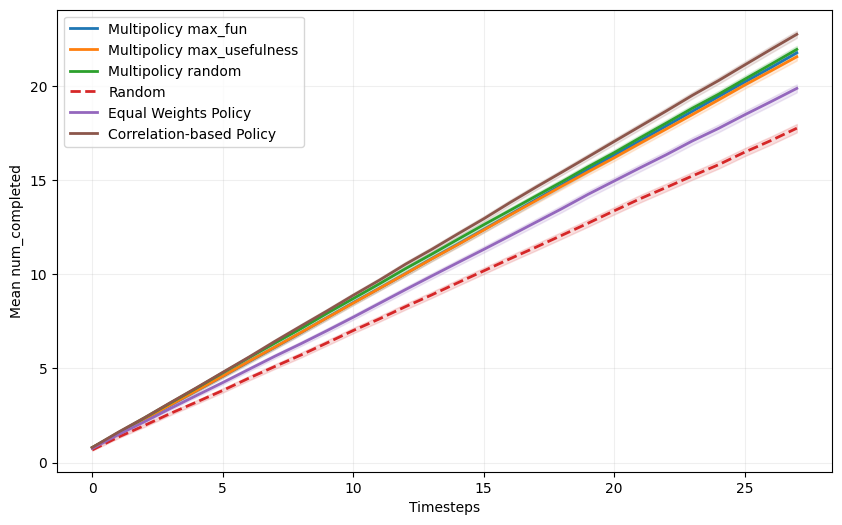

In [228]:
sim_utils.plot_simulation(choice_policies + baseline_policies, 'num_completed')

#### Inspect number of users per state

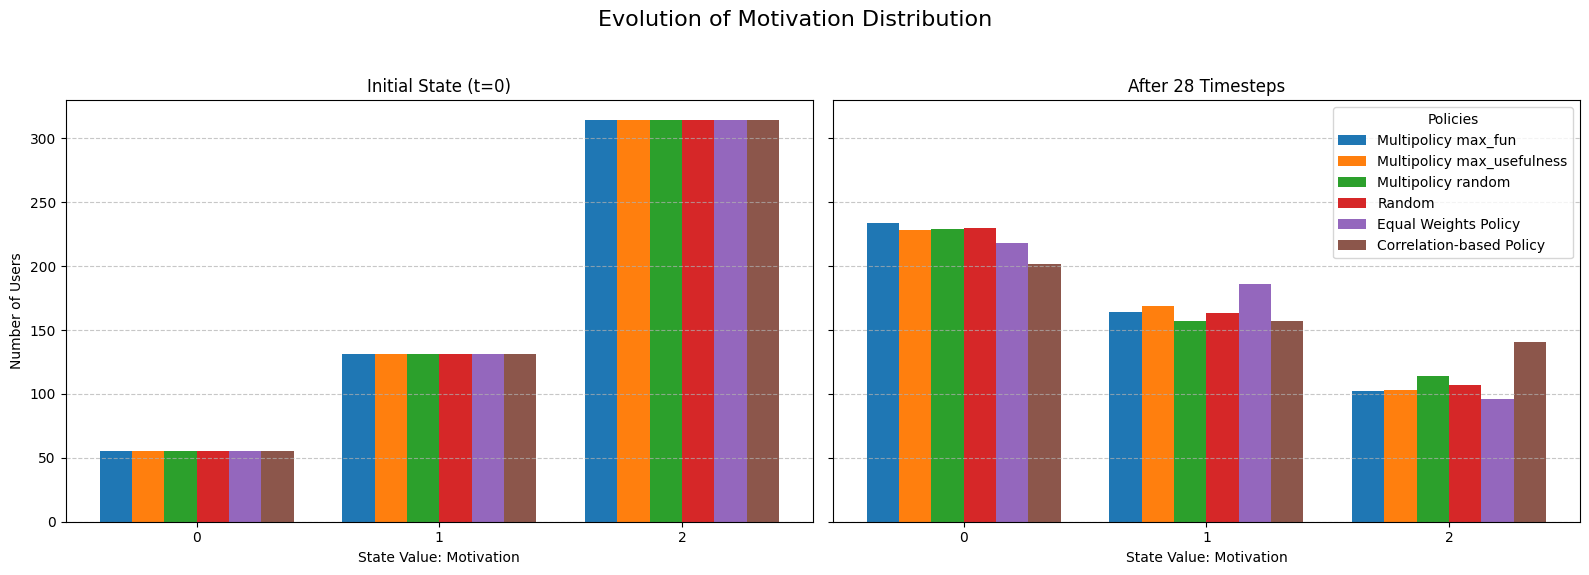

In [229]:
policies_to_inspect = choice_policies + baseline_policies
# 1. Configuration
target_feature = feature_names[-1]
feature_idx = feature_names.index(target_feature)
timesteps_to_plot = [0, -1]
titles = ["Initial State (t=0)", f"After {NUM_TIMESTEPS} Timesteps"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax_idx, t_idx in enumerate(timesteps_to_plot):
    all_counts = []
    max_val = 0
    
    # 2. Extract and Process Data
    for sim_res in policies_to_inspect:
        # Reshape to (Users, Timesteps, Features) and grab the specific time t_idx
        states = np.stack(sim_res['state']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)
        feature_values = states[:, t_idx, feature_idx].astype(int)
        
        counts = np.bincount(feature_values)
        all_counts.append(counts)
        max_val = max(max_val, len(counts))

    # Pad for uniform plotting
    processed_counts = [np.pad(c, (0, max_val - len(c)), 'constant') for c in all_counts]
    
    # 3. Plotting on the specific subplot
    x = np.arange(max_val)
    width = 0.8 / len(policies_to_inspect)
    
    for i, counts in enumerate(processed_counts):
        offset = (i - len(policies_to_inspect)/2) * width + width/2
        axes[ax_idx].bar(x + offset, counts, width, label=policies_to_inspect[i]['policy'].iloc[0])

    # Formatting Subplot
    axes[ax_idx].set_xlabel(f'State Value: {target_feature}')
    axes[ax_idx].set_title(titles[ax_idx])
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].grid(axis='y', linestyle='--', alpha=0.7)

axes[0].set_ylabel('Number of Users')
axes[1].legend(title="Policies", loc='upper right')

plt.suptitle(f'Evolution of {target_feature} Distribution', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

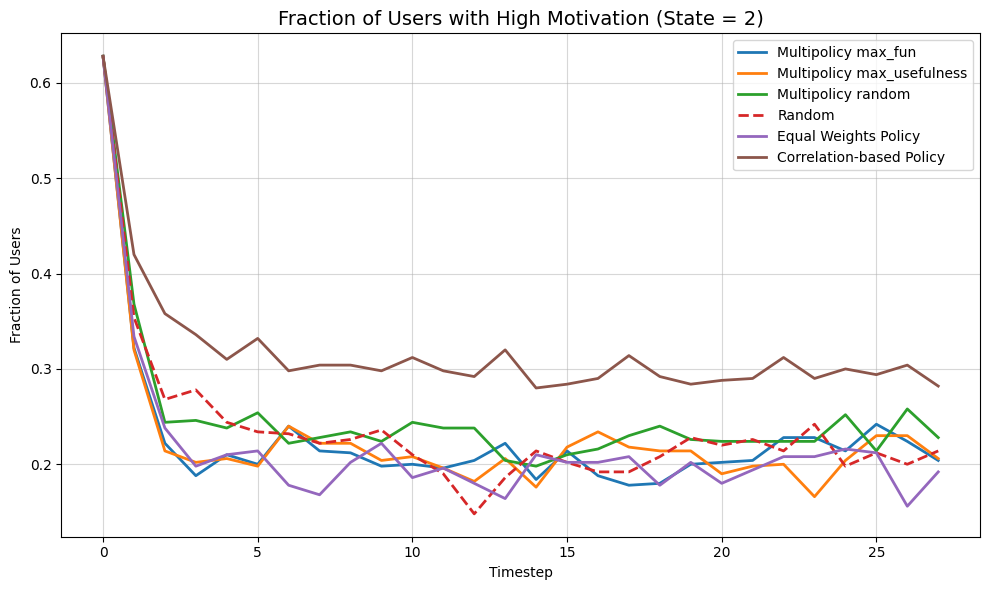

In [230]:
# 1. Setup threshold and indices
HIGH_MOTIVATION_THRESHOLD = 2 # Adjust based on your state scale (e.g., 0-10)
feature_idx = feature_names.index(target_feature)
timesteps = np.arange(NUM_TIMESTEPS)

plt.figure(figsize=(10, 6))

# 2. Calculate and plot the trend for each policy
for sim_res in policies_to_inspect:
    policy_label = sim_res['policy'].iloc[0]
    
    # Reshape states: (Users, Timesteps, Features)
    states = np.stack(sim_res['state']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)
    
    # Extract motivation and count users meeting the threshold at each step
    motivation_data = states[:, :, feature_idx]
    high_motivation_trend = np.sum(motivation_data >= HIGH_MOTIVATION_THRESHOLD, axis=0) / NUM_USERS
    
    # Plotting the line
    plt.plot(timesteps, high_motivation_trend, label=policy_label, linewidth=2, linestyle='--' if 'Random' in policy_label else '-')

# 3. Aesthetics and Labels
plt.title(f'Fraction of Users with High Motivation (State = {HIGH_MOTIVATION_THRESHOLD})', fontsize=14)
plt.xlabel('Timestep')
plt.ylabel('Fraction of Users')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

#### Inspect diversity

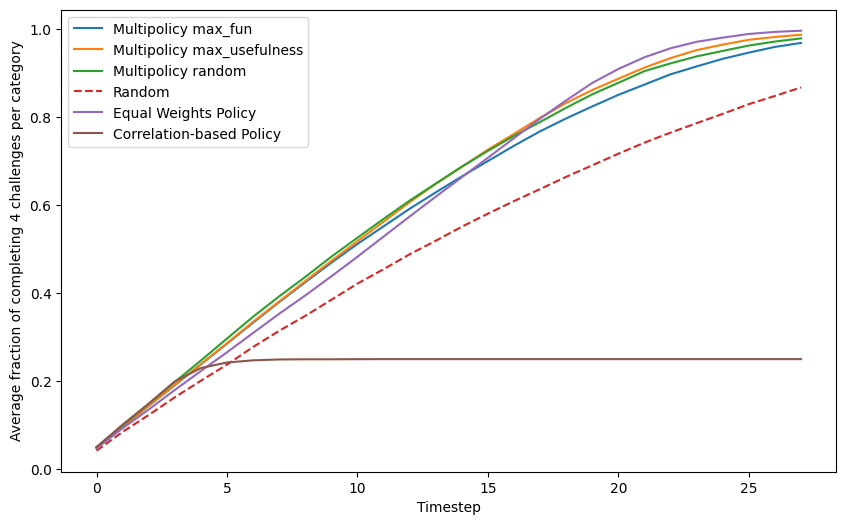

In [231]:
plt.figure(figsize=(10, 6))
for idx, sim_res in enumerate(choice_policies + [simulation_random, simulation_equal, simulation_corr]):
    counts_per_category = np.stack(sim_res['counts_per_category']).reshape(NUM_USERS, NUM_TIMESTEPS, -1)
    max_count_per_category = 4
    counts_per_category = np.clip(counts_per_category, 0, max_count_per_category)
    counts = counts_per_category.sum(axis=2)
    fraction_completed = counts / (max_count_per_category*4)
    mean_fraction_completed = fraction_completed.mean(axis=0)
    style = '--' if 'Random' in sim_res['policy'].iloc[0] else '-'
    plt.plot(mean_fraction_completed, label=sim_res['policy'].iloc[0], linestyle=style)
plt.xlabel('Timestep')
plt.ylabel(f'Average fraction of completing {max_count_per_category} challenges per category')
plt.legend()

#### Analyze dropout / retention

Multipolicy max_fun | Max Consecutive Non-completions: 6
Multipolicy max_fun | Average Max Consecutive Non-completions: 1.99
Multipolicy max_usefulness | Max Consecutive Non-completions: 6
Multipolicy max_usefulness | Average Max Consecutive Non-completions: 2.03
Multipolicy random | Max Consecutive Non-completions: 6
Multipolicy random | Average Max Consecutive Non-completions: 1.88
Random          | Max Consecutive Non-completions: 10
Random          | Average Max Consecutive Non-completions: 3.00
Equal Weights Policy | Max Consecutive Non-completions: 8
Equal Weights Policy | Average Max Consecutive Non-completions: 2.45
Correlation-based Policy | Max Consecutive Non-completions: 6
Correlation-based Policy | Average Max Consecutive Non-completions: 1.70


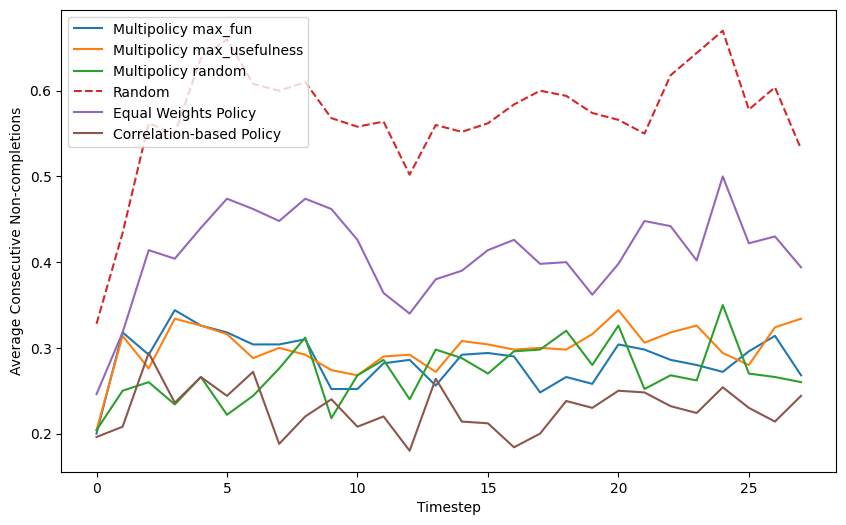

,Policy,Avg Max Streak,Median Max Streak,% Users with 5+ Day Non-completions,Final Avg Streak
5,Correlation-based Policy,1.698,2.0,1.0,0.244
2,Multipolicy random,1.878,2.0,1.4,0.260
0,Multipolicy max_fun,1.988,2.0,0.8,0.268
1,Multipolicy max_usefulness,2.034,2.0,1.2,0.334
4,Equal Weights Policy,2.446,2.0,5.2,0.394
3,Random,3.004,3.0,12.8,0.532


In [232]:
def get_consecutive_failures(df):
    # Group by user and find sequences of the same 'completed' value
    # 'block' increments every time 'completed' changes
    df = df.sort_values(['user', 't'])
    df['block'] = (df['completed'] != df.groupby('user')['completed'].shift()).cumsum()
    
    # Calculate the cumulative count within each block
    df['consecutive_no'] = df.groupby(['user', 'block']).cumcount() + 1
    
    # We only care about streaks where completed == 0
    df.loc[df['completed'] == 1, 'consecutive_no'] = 0
    return df

dropout_threshold = 5
summary_stats = []
plt.figure(figsize=(10, 6))
for sim_res in choice_policies + baseline_policies:
    sim_res = get_consecutive_failures(sim_res)
    mean_consecutive_no = sim_res.groupby('t')['consecutive_no'].mean()
    user_max_streaks = sim_res.groupby('user')['consecutive_no'].max()
    
    summary_stats.append({
        'Policy': sim_res['policy'].iloc[0],
        'Avg Max Streak': user_max_streaks.mean(),
        'Median Max Streak': user_max_streaks.median(),
        '% Users with 5+ Day Non-completions': (user_max_streaks >= 5).mean() * 100,
        'Final Avg Streak': sim_res[sim_res['t'] == sim_res['t'].max()]['consecutive_no'].mean()
    })
    print(f"{sim_res['policy'].iloc[0]:<15} | Max Consecutive Non-completions: {user_max_streaks.max()}")
    print(f"{sim_res['policy'].iloc[0]:<15} | Average Max Consecutive Non-completions: {user_max_streaks.mean():.2f}")

    plt.plot(mean_consecutive_no, label=sim_res['policy'].iloc[0], linestyle='--' if 'Random' in sim_res['policy'].iloc[0] else '-')
plt.xlabel('Timestep')
plt.ylabel('Average Consecutive Non-completions')
plt.legend()
plt.show()

df_comparison = pd.DataFrame(summary_stats)
df_comparison.sort_values('Avg Max Streak')


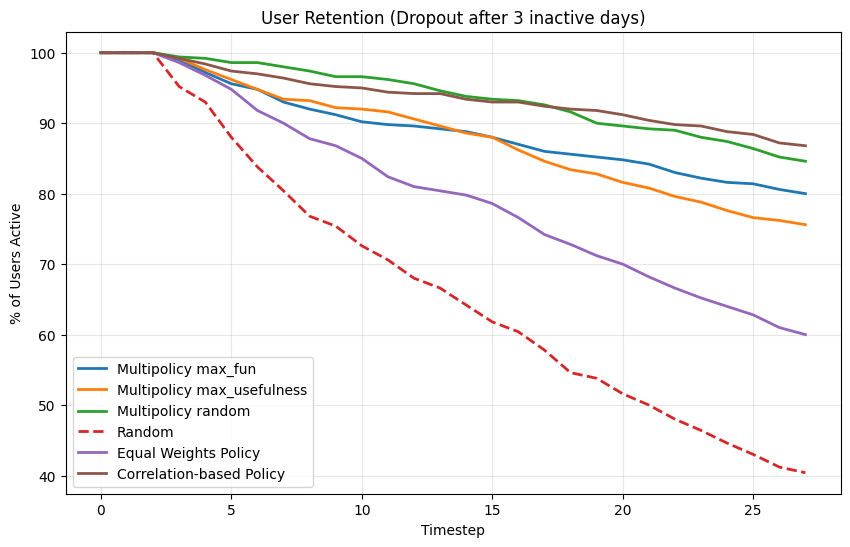

In [233]:
def apply_post_hoc_dropout(df, threshold=3):
    if 'consecutive_no' not in df.columns:
        df = get_consecutive_failures(df)
    
    dropouts = df[df['consecutive_no'] >= threshold]
    
    # Get the earliest timestep for each user where they dropped out
    first_dropout_t = dropouts.groupby(['policy', 'user'])['t'].min().reset_index()
    first_dropout_t.rename(columns={'t': 'dropout_time'}, inplace=True)
    
    df = df.merge(first_dropout_t, on=['policy', 'user'], how='left')
    
    # Keep rows where 't' <= 'dropout_time' 
    # (or keep all rows if dropout_time is NaN, meaning they never dropped out)
    df_active = df[(df['t'] <= df['dropout_time']) | (df['dropout_time'].isna())].copy()
    
    return df_active.drop(columns=['dropout_time'])

plt.figure(figsize=(10, 6))

for sim_res in choice_policies + baseline_policies:
    # Apply dropout
    df_active = apply_post_hoc_dropout(sim_res, threshold=3)
    
    # Count unique users at each t
    survival = df_active.groupby('t')['user'].nunique()
    # Normalize by starting count
    survival_rate = (survival / sim_res['user'].nunique()) * 100
    
    plt.plot(survival_rate, label=sim_res['policy'].iloc[0], linewidth=2, linestyle='--' if 'Random' in sim_res['policy'].iloc[0] else '-')

plt.ylabel("% of Users Active")
plt.xlabel("Timestep")
plt.title("User Retention (Dropout after 3 inactive days)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()